In [ ]:
# One-cell setup for fresh environments
%pip install -q pandas numpy scikit-learn xgboost catboost seaborn matplotlib openpyxl


THIS NOTEBOOK IS SAME PRACTICE AS RESEARCHERS CODE, WHERE OUR RESULTS IMPROVED. DON'T RUN THIS VERSION, MAKE A COPY SO RESULTS AREN'T OVERRIDDEN

# Construction Safety: Literal Author-Style Severity Notebook

This notebook is the checkpoint-friendly notebook version of [Construction_Injury_Severity.py](/Users/jakesilva/Construction-Safety/Construction_Injury_Severity.py).

It keeps the original author workflow recognizable while making one practical Colab-oriented improvement: each model family runs in its **own cell**, and each completed cell writes a saved artifact to disk.


This notebook intentionally preserves the : original feature behavior:

- all **non-target columns** are used as features
- text-like columns such as `abstract`, `event_keyword`, and `description` stay in
- outcome-adjacent columns such as `fatality` stay in
- the original six model families remain the core comparison set

The only structural changes are:

- use the premade `train / validation / test` CSV splits instead of the Excel file and `train_test_split`
- add standalone **CatBoost**
- add a **soft-voting ensemble** built from the six original model families
- save artifacts so each model can be rerun independently


In [ ]:
%pip install pandas numpy scikit-learn xgboost catboost seaborn matplotlib

import os
import pickle
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

MPLCONFIGDIR = (Path.cwd() / '.matplotlib').resolve()
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except Exception:
    sns = None
    SEABORN_AVAILABLE = False

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception:
    CatBoostClassifier = None
    CATBOOST_AVAILABLE = False

if SEABORN_AVAILABLE:
    sns.set_theme(style='whitegrid')
else:
    plt.style.use('default')

print('Seaborn available:', SEABORN_AVAILABLE)
print('XGBoost available:', XGBOOST_AVAILABLE)
print('CatBoost available:', CATBOOST_AVAILABLE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
Seaborn available: True
XGBoost available: True
CatBoost available: True


Mount Google Drive

In [ ]:
IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    drive = None

if IN_COLAB:
    drive.mount('/content/drive')
    print('Google Drive mounted.')
else:
    print('Not running inside Google Colab; Drive mount skipped.')


Mounted at /content/drive
Google Drive mounted.


Initializing Data paths and artifact storage

In [ ]:
NOTEBOOK_ROOT = Path.cwd()
DRIVE_ROOT = Path('/content/drive/MyDrive')
SHARED_DRIVE_PROJECT_DIR = DRIVE_ROOT / 'DS340W' / 'Coding' / "Jake's New Clean Code Implementation (April 9)"

TRAIN_FILENAME = 'construction_training_set_cleaned.csv'
VAL_FILENAME = 'construction_validation_set_cleaned.csv'
TEST_FILENAME = 'construction_test_set_cleaned.csv'

DATA_DIR_CANDIDATES = [
    SHARED_DRIVE_PROJECT_DIR / 'Data',
    SHARED_DRIVE_PROJECT_DIR,
    NOTEBOOK_ROOT / 'Data',
    Path('/content/Data'),
    Path('/content/Construction-Safety/Data'),
    Path('/content'),
    NOTEBOOK_ROOT,
]

DATA_DIR = None
for candidate in DATA_DIR_CANDIDATES:
    if (candidate / TRAIN_FILENAME).exists():
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        f'Could not find cleaned split CSVs ({TRAIN_FILENAME}, {VAL_FILENAME}, {TEST_FILENAME}) in Data/ or /content.'
    )

if DRIVE_ROOT.exists():
    ARTIFACT_ROOT = SHARED_DRIVE_PROJECT_DIR / 'literal_author_style_cleaned'
else:
    ARTIFACT_ROOT = NOTEBOOK_ROOT / 'outputs' / 'literal_author_style_cleaned'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / TRAIN_FILENAME
VAL_CSV = DATA_DIR / VAL_FILENAME
TEST_CSV = DATA_DIR / TEST_FILENAME
TARGET_COL = 'degree_of_inj_x'
MODEL_SELECTION_METRIC = 'weighted_f1'
RANDOM_STATE = 42
OVERWRITE_EXISTING_MODEL_ARTIFACTS = True

ORIGINAL_MODEL_ORDER = [
    'Logistic Regression (L1)',
    'Logistic Regression (L2)',
    'SVM',
    'Random Forest',
    'XGBoost',
    'MLP',
]
FULL_MODEL_ORDER = ORIGINAL_MODEL_ORDER + ['CatBoost', 'Soft Voting Ensemble']
MODEL_SLUGS = {
    'Logistic Regression (L1)': 'logistic_regression_l1',
    'Logistic Regression (L2)': 'logistic_regression_l2',
    'SVM': 'svm',
    'Random Forest': 'random_forest',
    'XGBoost': 'xgboost',
    'MLP': 'mlp',
    'CatBoost': 'catboost',
    'Soft Voting Ensemble': 'soft_voting_ensemble',
}

print('Notebook root:', NOTEBOOK_ROOT)
print('Data directory:', DATA_DIR)
print('Artifact root:', ARTIFACT_ROOT)
print('Training split:', TRAIN_CSV)
print('Validation split:', VAL_CSV)
print('Test split:', TEST_CSV)
print('Selection metric:', MODEL_SELECTION_METRIC)
print('Overwrite existing model artifacts:', OVERWRITE_EXISTING_MODEL_ARTIFACTS)
print('Using cleaned split files:', TRAIN_FILENAME, VAL_FILENAME, TEST_FILENAME)
if DRIVE_ROOT.exists():
    print('Artifacts will persist in Google Drive.')
else:
    print('Google Drive is not mounted; artifacts are local to this runtime/workspace.')
    print('If the Colab runtime fully resets, rerun the notebook after mounting Drive to keep checkpoints.')


Notebook root: /content
Data directory: /content
Artifact root: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned
Training split: /content/construction_training_set_cleaned.csv
Validation split: /content/construction_validation_set_cleaned.csv
Test split: /content/construction_test_set_cleaned.csv
Selection metric: weighted_f1
Overwrite existing model artifacts: True
Using cleaned split files: construction_training_set_cleaned.csv construction_validation_set_cleaned.csv construction_test_set_cleaned.csv
Artifacts will persist in Google Drive.


Load the Fixed Premade Data Splits


In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

assert list(train_df.columns) == list(val_df.columns) == list(test_df.columns), 'Split schemas are not aligned'
assert TARGET_COL in train_df.columns, f'Missing target column: {TARGET_COL}'

train_df = train_df.rename(columns=lambda x: str(x).strip()).dropna(subset=[TARGET_COL]).copy()
val_df = val_df.rename(columns=lambda x: str(x).strip()).dropna(subset=[TARGET_COL]).copy()
test_df = test_df.rename(columns=lambda x: str(x).strip()).dropna(subset=[TARGET_COL]).copy()

print('Shapes after dropping rows with missing target:')
print(' train:', train_df.shape)
print(' val  :', val_df.shape)
print(' test :', test_df.shape)

for split_name, frame in [('train', train_df), ('val', val_df), ('test', test_df)]:
    y_counts = pd.to_numeric(frame[TARGET_COL], errors='coerce').astype('Int64').value_counts(dropna=False).sort_index()
    y_props = (y_counts / len(frame)).round(4)
    print()
    print(f'{split_name} target distribution:')
    display(pd.DataFrame({'count': y_counts, 'prop': y_props}))

feature_columns = [c for c in train_df.columns if c != TARGET_COL]
print()
print('All non-target columns are retained in this notebook.')
print('Feature count:', len(feature_columns))
print('Feature columns:', feature_columns)


Shapes after dropping rows with missing target:
 train: (35485, 24)
 val  : (5070, 24)
 test : (10139, 24)

train target distribution:


,count,prop
degree_of_inj_x,,
0,34,0.001
1,13757,0.3877
2,17376,0.4897
3,4317,0.1217
4,1,0.0



val target distribution:


,count,prop
degree_of_inj_x,,
0,5,0.001
1,1965,0.3876
2,2482,0.4895
3,617,0.1217
4,1,0.0002



test target distribution:


,count,prop
degree_of_inj_x,,
0,9,0.0009
1,3931,0.3877
2,4965,0.4897
3,1234,0.1217



All non-target columns are retained in this notebook.
Feature count: 23
Feature columns: ['construction', 'state_x', 'city_x', 'zip_x', 'sic_code', 'date', 'fatality', 'age_x', 'sex_x', 'event_type', 'occ_code', 'event_keyword', 'abstract', 'temp', 'feels_like', 'pressure', 'humidity', 'clouds', 'visibility', 'wind_speed', 'wind_deg', 'main', 'description']


## Rebuild the Original Preprocessing Pattern

The original author file uses one shared preprocessing pipeline for the classic sklearn models:

- mean imputation + scaling for numeric columns
- constant imputation + one-hot encoding for categorical columns

So we kept that structure here. CatBoost gets its own training branch later because it naturally handles categorical features without the shared one-hot pipeline.


In [ ]:
def make_xy(frame):
    y = pd.to_numeric(frame[TARGET_COL], errors='coerce')
    if y.isna().any():
        raise ValueError(f'Non-numeric target values found in {TARGET_COL}')
    y = y.astype(int)

    X = frame.drop(columns=[TARGET_COL]).copy()
    X.columns = X.columns.astype(str)
    return X, y


X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)

assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), 'Feature columns do not align across splits'

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

for frame in [X_train, X_val, X_test]:
    for col in categorical_cols:
        frame[col] = frame[col].astype(str)

labels = sorted(set(y_train.unique()) | set(y_val.unique()) | set(y_test.unique()))
X_train_val = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_train_val = pd.concat([y_train, y_val], axis=0, ignore_index=True)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

print('Numeric feature count:', len(numerical_cols))
print('Categorical feature count:', len(categorical_cols))
print('Labels observed:', labels)


Numeric feature count: 14
Categorical feature count: 9
Labels observed: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## Shared Helpers and Checkpointing Logic

This cell defines all model-fitting helpers plus disk checkpointing. The per-model cells below call these helpers and save one artifact file per model family.


In [ ]:
# -----------------------------
# Candidate grids, metrics, checkpoint helpers, and runners
# -----------------------------
def metrics_bundle(y_true, y_pred, labels):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'weighted_precision': float(precision_score(y_true, y_pred, average='weighted', zero_division=0)),
        'weighted_recall': float(recall_score(y_true, y_pred, average='weighted', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'macro_precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'macro_recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'report': classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0),
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=labels),
    }


def align_proba_to_labels(proba, model_classes, labels):
    aligned = np.zeros((proba.shape[0], len(labels)), dtype=float)
    class_to_idx = {}
    for i, c in enumerate(model_classes):
        try:
            class_to_idx[int(c)] = i
        except Exception:
            class_to_idx[c] = i
    for j, lbl in enumerate(labels):
        if int(lbl) in class_to_idx:
            aligned[:, j] = proba[:, class_to_idx[int(lbl)]]
    return aligned


def probs_to_preds(proba, labels):
    label_array = np.asarray(labels, dtype=int)
    return label_array[np.argmax(proba, axis=1)]


def normalize_weights(score_map):
    clipped = {name: max(float(score), 0.0) for name, score in score_map.items()}
    total = sum(clipped.values())
    if total <= 0:
        uniform = 1.0 / max(len(clipped), 1)
        return {name: uniform for name in clipped}
    return {name: score / total for name, score in clipped.items()}


def model_candidates(model_name):
    if model_name == 'Logistic Regression (L1)':
        return [
            {'penalty': 'l1', 'solver': 'saga', 'max_iter': 5000, 'C': c, 'random_state': RANDOM_STATE}
            for c in [0.5, 1.0, 2.0]
        ]

    if model_name == 'Logistic Regression (L2)':
        return [
            {'penalty': 'l2', 'solver': 'saga', 'max_iter': 5000, 'C': c, 'random_state': RANDOM_STATE}
            for c in [0.5, 1.0, 2.0]
        ]

    if model_name == 'SVM':
        return [
            {'C': c, 'kernel': 'rbf', 'gamma': 'scale', 'probability': True, 'random_state': RANDOM_STATE}
            for c in [1.0, 2.0]
        ]

    if model_name == 'Random Forest':
        return [
            {'n_estimators': n, 'random_state': RANDOM_STATE, 'n_jobs': -1}
            for n in [100, 300]
        ] + [
            {'n_estimators': 300, 'max_depth': 20, 'random_state': RANDOM_STATE, 'n_jobs': -1}
        ]

    if model_name == 'XGBoost':
        if not XGBOOST_AVAILABLE:
            return []
        return [
            {
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'learning_rate': learning_rate,
                'subsample': 1.0,
                'colsample_bytree': 1.0,
                'random_state': RANDOM_STATE,
                'n_jobs': -1,
                'objective': 'multi:softprob',
                'eval_metric': 'mlogloss',
            }
            for (n_estimators, max_depth, learning_rate) in [(200, 6, 0.1), (400, 6, 0.05)]
        ]

    if model_name == 'MLP':
        return [
            {'hidden_layer_sizes': hidden, 'max_iter': 500, 'random_state': RANDOM_STATE}
            for hidden in [(100,), (150,)]
        ]

    if model_name == 'CatBoost':
        if not CATBOOST_AVAILABLE:
            return []
        return [
            {
                'iterations': iterations,
                'depth': depth,
                'learning_rate': learning_rate,
                'loss_function': 'MultiClass',
                'random_seed': RANDOM_STATE,
                'verbose': False,
                'allow_writing_files': False,
            }
            for (iterations, depth, learning_rate) in [(300, 6, 0.1), (500, 6, 0.05), (500, 8, 0.05)]
        ]

    raise ValueError(f'Unsupported model: {model_name}')


def make_sklearn_estimator(model_name, params):
    if model_name == 'Logistic Regression (L1)':
        return LogisticRegression(**params)
    if model_name == 'Logistic Regression (L2)':
        return LogisticRegression(**params)
    if model_name == 'SVM':
        return SVC(**params)
    if model_name == 'Random Forest':
        return RandomForestClassifier(**params)
    if model_name == 'XGBoost':
        return XGBClassifier(**params)
    if model_name == 'MLP':
        return MLPClassifier(**params)
    raise ValueError(model_name)


def fit_predict_proba_sklearn(model_name, params, X_fit, y_fit, X_pred):
    local_preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical_cols),
            ('cat', categorical_transformer, categorical_cols),
        ]
    )
    estimator = make_sklearn_estimator(model_name, params)
    pipeline = Pipeline(steps=[('preprocessor', local_preprocessor), ('classifier', estimator)])
    pipeline.fit(X_fit, y_fit)
    pred = np.asarray(pipeline.predict(X_pred))
    proba = np.asarray(pipeline.predict_proba(X_pred))
    classes = pipeline.named_steps['classifier'].classes_
    return pred, proba, classes


def prepare_catboost_frames(X_fit, X_pred):
    X_fit_cb = X_fit.copy()
    X_pred_cb = X_pred.copy()

    numeric_cols_cb = X_fit_cb.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols_cb = [c for c in X_fit_cb.columns if c not in numeric_cols_cb]

    for column in categorical_cols_cb:
        X_fit_cb[column] = X_fit_cb[column].astype('object').where(~X_fit_cb[column].isna(), 'missing').astype(str)
        X_pred_cb[column] = X_pred_cb[column].astype('object').where(~X_pred_cb[column].isna(), 'missing').astype(str)

    cat_feature_indices = [X_fit_cb.columns.get_loc(column) for column in categorical_cols_cb]
    return X_fit_cb, X_pred_cb, cat_feature_indices


def fit_predict_proba_catboost(params, X_fit, y_fit, X_pred):
    X_fit_cb, X_pred_cb, cat_feature_indices = prepare_catboost_frames(X_fit, X_pred)
    model = CatBoostClassifier(**params)
    model.fit(X_fit_cb, y_fit, cat_features=cat_feature_indices)
    pred = np.asarray(model.predict(X_pred_cb)).reshape(-1).astype(int)
    proba = np.asarray(model.predict_proba(X_pred_cb))
    classes = model.classes_
    return pred, proba, classes


def artifact_path(model_name):
    return ARTIFACT_ROOT / f"{MODEL_SLUGS[model_name]}.pkl"


def save_artifact(model_name, artifact):
    artifact = dict(artifact)
    artifact['model_name'] = model_name
    artifact['artifact_path'] = str(artifact_path(model_name))
    with artifact_path(model_name).open('wb') as handle:
        pickle.dump(artifact, handle)
    print('Saved artifact to:', artifact_path(model_name))
    return artifact


def load_artifact(model_name, required=False):
    path = artifact_path(model_name)
    if not path.exists():
        if required:
            raise FileNotFoundError(f'Missing artifact for {model_name}: {path}')
        return None
    with path.open('rb') as handle:
        return pickle.load(handle)


def load_all_artifacts():
    artifacts = {}
    for model_name in FULL_MODEL_ORDER:
        artifact = load_artifact(model_name, required=False)
        if artifact is not None:
            artifacts[model_name] = artifact
    return artifacts


def build_summary_frames(artifacts):
    validation_rows = []
    test_rows = []
    candidate_rows = []

    for model_name in FULL_MODEL_ORDER:
        artifact = artifacts.get(model_name)
        if not artifact or artifact.get('status') != 'completed':
            continue

        validation_rows.append({
            'Model': model_name,
            'Accuracy': artifact['val_metrics']['accuracy'],
            'Precision': artifact['val_metrics']['weighted_precision'],
            'Recall': artifact['val_metrics']['weighted_recall'],
            'F1-score': artifact['val_metrics']['weighted_f1'],
            'Macro-F1': artifact['val_metrics']['macro_f1'],
            'Best Candidate': artifact.get('best_candidate_index'),
        })
        test_rows.append({
            'Model': model_name,
            'Accuracy': artifact['test_metrics']['accuracy'],
            'Precision': artifact['test_metrics']['weighted_precision'],
            'Recall': artifact['test_metrics']['weighted_recall'],
            'F1-score': artifact['test_metrics']['weighted_f1'],
            'Macro-F1': artifact['test_metrics']['macro_f1'],
            'Best Candidate': artifact.get('best_candidate_index'),
        })
        for row in artifact.get('candidate_rows', []):
            candidate_rows.append(row)

    validation_summary_df = pd.DataFrame(validation_rows)
    if len(validation_summary_df):
        validation_summary_df = validation_summary_df.sort_values(by='F1-score', ascending=False).reset_index(drop=True)

    test_summary_df = pd.DataFrame(test_rows)
    if len(test_summary_df):
        test_summary_df = test_summary_df.sort_values(by='F1-score', ascending=False).reset_index(drop=True)

    candidate_summary_df = pd.DataFrame(candidate_rows)
    if len(candidate_summary_df):
        candidate_summary_df = candidate_summary_df.sort_values(['Model', 'Val Weighted F1'], ascending=[True, False]).reset_index(drop=True)

    ensemble_weights_df = pd.DataFrame()
    ensemble_artifact = artifacts.get('Soft Voting Ensemble')
    if ensemble_artifact and ensemble_artifact.get('status') == 'completed':
        ensemble_weights_df = pd.DataFrame([
            {
                'Member Model': model_name,
                'Validation Weighted F1': artifacts[model_name]['val_metrics']['weighted_f1'],
                'Soft Vote Weight': ensemble_artifact['member_weights'][model_name],
            }
            for model_name in ensemble_artifact['member_names']
        ]).sort_values('Soft Vote Weight', ascending=False).reset_index(drop=True)

    return validation_summary_df, test_summary_df, candidate_summary_df, ensemble_weights_df


def display_artifact_report(artifact):
    model_name = artifact['model_name']
    print()
    print(f'=== {model_name} ===')
    if model_name == 'Soft Voting Ensemble':
        print('Member models:', artifact['member_names'])
        print('Member weights:', {name: round(weight, 4) for name, weight in artifact['member_weights'].items()})
    else:
        print('Best candidate index:', artifact['best_candidate_index'])
        print('Best candidate params:', artifact['best_candidate_params'])

    print('Artifact path:', artifact['artifact_path'])
    print('Validation metrics:')
    print({k: round(v, 4) for k, v in artifact['val_metrics'].items() if k not in ['report', 'confusion_matrix']})
    val_report_df = pd.DataFrame(artifact['val_metrics']['report']).T
    keep_cols = [c for c in ['precision', 'recall', 'f1-score', 'support'] if c in val_report_df.columns]
    display(val_report_df[keep_cols])

    print('Test metrics:')
    print({k: round(v, 4) for k, v in artifact['test_metrics'].items() if k not in ['report', 'confusion_matrix']})
    test_report_df = pd.DataFrame(artifact['test_metrics']['report']).T
    display(test_report_df[keep_cols])

    test_cm_df = pd.DataFrame(
        artifact['test_metrics']['confusion_matrix'],
        index=[f'true_{label}' for label in labels],
        columns=[f'pred_{label}' for label in labels],
    )
    print('Test confusion matrix:')
    display(test_cm_df)


def run_model_family(model_name, force=False):
    existing_artifact = load_artifact(model_name, required=False)
    if (
        existing_artifact is not None
        and existing_artifact.get('status') == 'completed'
        and not force
        and not OVERWRITE_EXISTING_MODEL_ARTIFACTS
    ):
        print()
        print(f'=== {model_name} already completed; loading saved artifact ===')
        print('To retrain this model, call run_model_family(model_name, force=True).')
        display_artifact_report(existing_artifact)
        return existing_artifact

    print()
    print(f'=== Running {model_name} ===')
    candidates = model_candidates(model_name)

    if not candidates:
        artifact = save_artifact(model_name, {
            'status': 'skipped',
            'reason': 'Dependency unavailable or no candidates configured.',
            'candidate_rows': [],
        })
        return artifact

    best_candidate = None
    best_candidate_index = None
    best_score = -np.inf
    best_val_metrics = None
    best_val_pred = None
    best_val_proba = None
    candidate_rows = []

    for idx, params in enumerate(candidates, start=1):
        try:
            if model_name == 'CatBoost':
                val_pred_raw, val_proba_raw, val_classes = fit_predict_proba_catboost(params, X_train, y_train, X_val)
            else:
                val_pred_raw, val_proba_raw, val_classes = fit_predict_proba_sklearn(model_name, params, X_train, y_train, X_val)

            val_proba = align_proba_to_labels(np.asarray(val_proba_raw), val_classes, labels)
            val_pred = probs_to_preds(val_proba, labels)
            val_metrics = metrics_bundle(y_val.to_numpy(), val_pred, labels)
            score = val_metrics[MODEL_SELECTION_METRIC]

            candidate_row = {
                'Model': model_name,
                'Candidate': idx,
                'Params': str(params),
                'Val Accuracy': val_metrics['accuracy'],
                'Val Weighted Precision': val_metrics['weighted_precision'],
                'Val Weighted Recall': val_metrics['weighted_recall'],
                'Val Weighted F1': val_metrics['weighted_f1'],
                'Val Macro F1': val_metrics['macro_f1'],
            }
            candidate_rows.append(candidate_row)

            print(f'Candidate {idx}: val_weighted_f1={val_metrics["weighted_f1"]:.4f}')
            if score > best_score:
                best_candidate = params
                best_candidate_index = idx
                best_score = score
                best_val_metrics = val_metrics
                best_val_pred = val_pred
                best_val_proba = val_proba
        except Exception as exc:
            print(f'Candidate {idx} failed: {type(exc).__name__}: {exc}')

    if best_candidate is None:
        artifact = save_artifact(model_name, {
            'status': 'failed',
            'reason': 'All candidates failed.',
            'candidate_rows': candidate_rows,
        })
        return artifact

    if model_name == 'CatBoost':
        test_pred_raw, test_proba_raw, test_classes = fit_predict_proba_catboost(best_candidate, X_train_val, y_train_val, X_test)
    else:
        test_pred_raw, test_proba_raw, test_classes = fit_predict_proba_sklearn(model_name, best_candidate, X_train_val, y_train_val, X_test)

    test_proba = align_proba_to_labels(np.asarray(test_proba_raw), test_classes, labels)
    test_pred = probs_to_preds(test_proba, labels)
    test_metrics = metrics_bundle(y_test.to_numpy(), test_pred, labels)

    print(f'Selected candidate {best_candidate_index} | test_weighted_f1={test_metrics["weighted_f1"]:.4f}')

    artifact = save_artifact(model_name, {
        'status': 'completed',
        'selection_metric': MODEL_SELECTION_METRIC,
        'labels': list(map(int, labels)),
        'best_candidate_index': best_candidate_index,
        'best_candidate_params': best_candidate,
        'candidate_rows': candidate_rows,
        'val_metrics': best_val_metrics,
        'val_pred': best_val_pred,
        'val_proba': best_val_proba,
        'test_metrics': test_metrics,
        'test_pred': test_pred,
        'test_proba': test_proba,
    })
    display_artifact_report(artifact)
    return artifact


def run_soft_voting_ensemble(force=False):
    existing_artifact = load_artifact('Soft Voting Ensemble', required=False)
    if (
        existing_artifact is not None
        and existing_artifact.get('status') == 'completed'
        and not force
    ):
        print()
        print('=== Soft Voting Ensemble already completed; loading saved artifact ===')
        print('If you reran any base-model cell, call run_soft_voting_ensemble(force=True) to refresh the ensemble.')
        display_artifact_report(existing_artifact)
        return existing_artifact

    print()
    print('=== Running Soft Voting Ensemble ===')
    artifacts = {}
    missing = []
    incomplete = []
    for model_name in ORIGINAL_MODEL_ORDER:
        artifact = load_artifact(model_name, required=False)
        if artifact is None:
            missing.append(model_name)
            continue
        artifacts[model_name] = artifact
        if artifact.get('status') != 'completed':
            incomplete.append(model_name)

    if missing or incomplete:
        artifact = save_artifact('Soft Voting Ensemble', {
            'status': 'skipped',
            'missing_members': missing,
            'incomplete_members': incomplete,
            'candidate_rows': [],
            'reason': 'Run and complete the six original model-family cells before building the ensemble.',
        })
        print('Ensemble skipped.')
        print('Missing members:', missing)
        print('Incomplete members:', incomplete)
        return artifact

    ensemble_raw_scores = {
        model_name: artifacts[model_name]['val_metrics']['weighted_f1']
        for model_name in ORIGINAL_MODEL_ORDER
    }
    ensemble_weights = normalize_weights(ensemble_raw_scores)

    ensemble_val_proba = np.zeros_like(artifacts[ORIGINAL_MODEL_ORDER[0]]['val_proba'])
    ensemble_test_proba = np.zeros_like(artifacts[ORIGINAL_MODEL_ORDER[0]]['test_proba'])
    for model_name in ORIGINAL_MODEL_ORDER:
        ensemble_val_proba += ensemble_weights[model_name] * artifacts[model_name]['val_proba']
        ensemble_test_proba += ensemble_weights[model_name] * artifacts[model_name]['test_proba']

    ensemble_val_pred = probs_to_preds(ensemble_val_proba, labels)
    ensemble_test_pred = probs_to_preds(ensemble_test_proba, labels)
    ensemble_val_metrics = metrics_bundle(y_val.to_numpy(), ensemble_val_pred, labels)
    ensemble_test_metrics = metrics_bundle(y_test.to_numpy(), ensemble_test_pred, labels)

    print(f'Validation weighted F1: {ensemble_val_metrics["weighted_f1"]:.4f}')
    print(f'Test weighted F1: {ensemble_test_metrics["weighted_f1"]:.4f}')

    artifact = save_artifact('Soft Voting Ensemble', {
        'status': 'completed',
        'selection_metric': MODEL_SELECTION_METRIC,
        'labels': list(map(int, labels)),
        'member_names': ORIGINAL_MODEL_ORDER,
        'member_weights': ensemble_weights,
        'candidate_rows': [],
        'val_metrics': ensemble_val_metrics,
        'val_pred': ensemble_val_pred,
        'val_proba': ensemble_val_proba,
        'test_metrics': ensemble_test_metrics,
        'test_pred': ensemble_test_pred,
        'test_proba': ensemble_test_proba,
    })
    display_artifact_report(artifact)
    return artifact


## Run One Model Per Cell

Each cell below trains one model family and writes one checkpoint artifact. This reduces time to retrain if the session times out since it takes a long time to train


### Logistic Regression (L1)

In [ ]:
lr_l1_artifact = run_model_family('Logistic Regression (L1)')


=== Running Logistic Regression (L1) ===
Candidate 1: val_weighted_f1=0.7558
Candidate 2: val_weighted_f1=0.7731
Candidate 3: val_weighted_f1=0.7809
Selected candidate 3 | test_weighted_f1=0.7903
Saved artifact to: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/logistic_regression_l1.pkl

=== Logistic Regression (L1) ===
Best candidate index: 3
Best candidate params: {'penalty': 'l1', 'solver': 'saga', 'max_iter': 5000, 'C': 2.0, 'random_state': 42}
Artifact path: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/logistic_regression_l1.pkl
Validation metrics:
{'accuracy': 0.8097, 'weighted_precision': 0.7842, 'weighted_recall': 0.8097, 'weighted_f1': 0.7809, 'macro_precision': 0.6292, 'macro_recall': 0.5063, 'macro_f1': 0.5355}


,precision,recall,f1-score,support
0,1.000000,0.600000,0.750000,5.000000
1,0.909418,0.899237,0.904299,1965.000000
2,0.761969,0.910556,0.829662,2482.000000
3,0.474684,0.121556,0.193548,617.000000
4,0.000000,0.000000,0.000000,1.000000
accuracy,0.809665,0.809665,0.809665,0.809665
macro avg,0.629214,0.506270,0.535502,5070.000000
weighted avg,0.784239,0.809665,0.780935,5070.000000


Test metrics:
{'accuracy': 0.8179, 'weighted_precision': 0.7926, 'weighted_recall': 0.8179, 'weighted_f1': 0.7903, 'macro_precision': 0.7888, 'macro_recall': 0.7381, 'macro_f1': 0.7382}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,9.000000
1,0.929375,0.903841,0.916430,3931.000000
2,0.766806,0.921249,0.836962,4965.000000
3,0.459064,0.127229,0.199239,1234.000000
4,0.000000,0.000000,0.000000,0.000000
accuracy,0.817931,0.817931,0.817931,0.817931
macro avg,0.631049,0.590464,0.590526,10139.000000
weighted avg,0.792588,0.817931,0.790301,10139.000000


Test confusion matrix:


,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,9,0,0,0,0
true_1,0,3553,356,22,0
true_2,0,228,4574,163,0
true_3,0,42,1035,157,0
true_4,0,0,0,0,0


### Logistic Regression (L2)

In [ ]:
lr_l2_artifact = run_model_family('Logistic Regression (L2)')


=== Running Logistic Regression (L2) ===
Candidate 1: val_weighted_f1=0.7694
Candidate 2: val_weighted_f1=0.7763
Candidate 3: val_weighted_f1=0.7811
Selected candidate 3 | test_weighted_f1=0.7875
Saved artifact to: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/logistic_regression_l2.pkl

=== Logistic Regression (L2) ===
Best candidate index: 3
Best candidate params: {'penalty': 'l2', 'solver': 'saga', 'max_iter': 5000, 'C': 2.0, 'random_state': 42}
Artifact path: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/logistic_regression_l2.pkl
Validation metrics:
{'accuracy': 0.8099, 'weighted_precision': 0.7921, 'weighted_recall': 0.8099, 'weighted_f1': 0.7811, 'macro_precision': 0.6423, 'macro_recall': 0.5064, 'macro_f1': 0.5371}


,precision,recall,f1-score,support
0,1.000000,0.600000,0.750000,5.000000
1,0.918389,0.881934,0.899792,1965.000000
2,0.755189,0.923449,0.830886,2482.000000
3,0.537931,0.126418,0.204724,617.000000
4,0.000000,0.000000,0.000000,1.000000
accuracy,0.809862,0.809862,0.809862,0.809862
macro avg,0.642302,0.506360,0.537081,5070.000000
weighted avg,0.792094,0.809862,0.781147,5070.000000


Test metrics:
{'accuracy': 0.8148, 'weighted_precision': 0.7959, 'weighted_recall': 0.8148, 'weighted_f1': 0.7875, 'macro_precision': 0.7996, 'macro_recall': 0.7364, 'macro_f1': 0.7383}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,9.000000
1,0.933459,0.881455,0.906712,3931.000000
2,0.758615,0.931118,0.836061,4965.000000
3,0.506173,0.132901,0.210526,1234.000000
4,0.000000,0.000000,0.000000,0.000000
accuracy,0.814775,0.814775,0.814775,0.814775
macro avg,0.639649,0.589095,0.590660,10139.000000
weighted avg,0.795894,0.814775,0.787466,10139.000000


Test confusion matrix:


,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,9,0,0,0,0
true_1,0,3465,440,26,0
true_2,0,208,4623,134,0
true_3,0,39,1031,164,0
true_4,0,0,0,0,0


### SVM

In [ ]:
svm_artifact = run_model_family('SVM')


=== Running SVM ===
Candidate 1: val_weighted_f1=0.7658
Candidate 2: val_weighted_f1=0.7721
Selected candidate 2 | test_weighted_f1=0.7789
Saved artifact to: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/svm.pkl

=== SVM ===
Best candidate index: 2
Best candidate params: {'C': 2.0, 'kernel': 'rbf', 'gamma': 'scale', 'probability': True, 'random_state': 42}
Artifact path: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/svm.pkl
Validation metrics:
{'accuracy': 0.812, 'weighted_precision': 0.8033, 'weighted_recall': 0.812, 'weighted_f1': 0.7721, 'macro_precision': 0.6673, 'macro_recall': 0.4984, 'macro_f1': 0.5197}


,precision,recall,f1-score,support
0,1.000000,0.600000,0.750000,5.000000
1,0.901373,0.902290,0.901831,1965.000000
2,0.756570,0.927881,0.833514,2482.000000
3,0.678571,0.061588,0.112927,617.000000
4,0.000000,0.000000,0.000000,1.000000
accuracy,0.812032,0.812032,0.812032,0.812032
macro avg,0.667303,0.498352,0.519655,5070.000000
weighted avg,0.803291,0.812032,0.772053,5070.000000


Test metrics:
{'accuracy': 0.8171, 'weighted_precision': 0.8061, 'weighted_recall': 0.8171, 'weighted_f1': 0.7789, 'macro_precision': 0.8299, 'macro_recall': 0.7269, 'macro_f1': 0.7184}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,9.000000
1,0.918114,0.901297,0.909628,3931.000000
2,0.757171,0.935750,0.837042,4965.000000
3,0.644444,0.070502,0.127100,1234.000000
4,0.000000,0.000000,0.000000,0.000000
accuracy,0.817142,0.817142,0.817142,0.817142
macro avg,0.663946,0.581510,0.574754,10139.000000
weighted avg,0.806066,0.817142,0.778923,10139.000000


Test confusion matrix:


,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,9,0,0,0,0
true_1,0,3543,382,6,0
true_2,0,277,4646,42,0
true_3,0,39,1108,87,0
true_4,0,0,0,0,0


### Random Forest

In [ ]:
random_forest_artifact = run_model_family('Random Forest')


=== Running Random Forest ===
Candidate 1: val_weighted_f1=0.7621
Candidate 2: val_weighted_f1=0.7645
Candidate 3: val_weighted_f1=0.7040
Selected candidate 2 | test_weighted_f1=0.7673
Saved artifact to: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/random_forest.pkl

=== Random Forest ===
Best candidate index: 2
Best candidate params: {'n_estimators': 300, 'random_state': 42, 'n_jobs': -1}
Artifact path: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/random_forest.pkl
Validation metrics:
{'accuracy': 0.8043, 'weighted_precision': 0.8178, 'weighted_recall': 0.8043, 'weighted_f1': 0.7645, 'macro_precision': 0.6926, 'macro_recall': 0.4927, 'macro_f1': 0.5154}


,precision,recall,f1-score,support
0,1.000000,0.600000,0.750000,5.000000
1,0.928532,0.852926,0.889125,1965.000000
2,0.734535,0.952055,0.829268,2482.000000
3,0.800000,0.058347,0.108761,617.000000
4,0.000000,0.000000,0.000000,1.000000
accuracy,0.804339,0.804339,0.804339,0.804339
macro avg,0.692613,0.492666,0.515431,5070.000000
weighted avg,0.817807,0.804339,0.764542,5070.000000


Test metrics:
{'accuracy': 0.8073, 'weighted_precision': 0.8228, 'weighted_recall': 0.8073, 'weighted_f1': 0.7673, 'macro_precision': 0.87, 'macro_recall': 0.7167, 'macro_f1': 0.7079}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,9.000000
1,0.937852,0.848385,0.890878,3931.000000
2,0.735430,0.960725,0.833115,4965.000000
3,0.806818,0.057536,0.107413,1234.000000
4,0.000000,0.000000,0.000000,0.000000
accuracy,0.807279,0.807279,0.807279,0.807279
macro avg,0.696020,0.573329,0.566281,10139.000000
weighted avg,0.822834,0.807279,0.767334,10139.000000


Test confusion matrix:


,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,9,0,0,0,0
true_1,0,3335,589,7,0
true_2,0,185,4770,10,0
true_3,0,36,1127,71,0
true_4,0,0,0,0,0


### XGBoost

In [ ]:
xgboost_artifact = run_model_family('XGBoost')


=== Running XGBoost ===
Candidate 1: val_weighted_f1=0.7738
Candidate 2: val_weighted_f1=0.7723
Selected candidate 1 | test_weighted_f1=0.7746
Saved artifact to: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/xgboost.pkl

=== XGBoost ===
Best candidate index: 1
Best candidate params: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'random_state': 42, 'n_jobs': -1, 'objective': 'multi:softprob', 'eval_metric': 'mlogloss'}
Artifact path: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/xgboost.pkl
Validation metrics:
{'accuracy': 0.8134, 'weighted_precision': 0.7948, 'weighted_recall': 0.8134, 'weighted_f1': 0.7738, 'macro_precision': 0.6504, 'macro_recall': 0.5787, 'macro_f1': 0.5699}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,5.000000
1,0.907794,0.906870,0.907332,1965.000000
2,0.756828,0.926672,0.833182,2482.000000
3,0.587302,0.059968,0.108824,617.000000
4,0.000000,0.000000,0.000000,1.000000
accuracy,0.813412,0.813412,0.813412,0.813412
macro avg,0.650385,0.578702,0.569868,5070.000000
weighted avg,0.794798,0.813412,0.773769,5070.000000


Test metrics:
{'accuracy': 0.817, 'weighted_precision': 0.8027, 'weighted_recall': 0.817, 'weighted_f1': 0.7746, 'macro_precision': 0.8251, 'macro_recall': 0.7226, 'macro_f1': 0.7083}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,9.000000
1,0.912711,0.909692,0.911199,3931.000000
2,0.758288,0.935146,0.837482,4965.000000
3,0.629213,0.045381,0.084656,1234.000000
4,0.000000,0.000000,0.000000,0.000000
accuracy,0.817043,0.817043,0.817043,0.817043
macro avg,0.660042,0.578044,0.566667,10139.000000
weighted avg,0.802665,0.817043,0.774582,10139.000000


Test confusion matrix:


,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,9,0,0,0,0
true_1,0,3576,351,4,0
true_2,0,293,4643,29,0
true_3,0,49,1129,56,0
true_4,0,0,0,0,0


### MLP

In [ ]:
mlp_artifact = run_model_family('MLP')


=== Running MLP ===
Candidate 1: val_weighted_f1=0.7923
Candidate 2: val_weighted_f1=0.7870
Selected candidate 1 | test_weighted_f1=0.7945
Saved artifact to: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/mlp.pkl

=== MLP ===
Best candidate index: 1
Best candidate params: {'hidden_layer_sizes': (100,), 'max_iter': 500, 'random_state': 42}
Artifact path: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/mlp.pkl
Validation metrics:
{'accuracy': 0.8195, 'weighted_precision': 0.7977, 'weighted_recall': 0.8195, 'weighted_f1': 0.7923, 'macro_precision': 0.6423, 'macro_recall': 0.514, 'macro_f1': 0.5452}


,precision,recall,f1-score,support
0,1.000000,0.600000,0.750000,5.000000
1,0.915730,0.912468,0.914096,1965.000000
2,0.772186,0.914988,0.837544,2482.000000
3,0.523810,0.142626,0.224204,617.000000
4,0.000000,0.000000,0.000000,1.000000
accuracy,0.819527,0.819527,0.819527,0.819527
macro avg,0.642345,0.514016,0.545169,5070.000000
weighted avg,0.797666,0.819527,0.792321,5070.000000


Test metrics:
{'accuracy': 0.8153, 'weighted_precision': 0.7923, 'weighted_recall': 0.8153, 'weighted_f1': 0.7945, 'macro_precision': 0.7826, 'macro_recall': 0.7451, 'macro_f1': 0.7491}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,9.000000
1,0.932632,0.901552,0.916828,3931.000000
2,0.771870,0.906344,0.833719,4965.000000
3,0.426000,0.172609,0.245675,1234.000000
4,0.000000,0.000000,0.000000,0.000000
accuracy,0.815268,0.815268,0.815268,0.815268
macro avg,0.626100,0.596101,0.599244,10139.000000
weighted avg,0.792306,0.815268,0.794519,10139.000000


Test confusion matrix:


,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,9,0,0,0,0
true_1,0,3544,347,40,0
true_2,0,218,4500,247,0
true_3,0,38,983,213,0
true_4,0,0,0,0,0


# Novel Implementation 1: CatBoost

In [ ]:
catboost_artifact = run_model_family('CatBoost')


=== Running CatBoost ===
Candidate 1: val_weighted_f1=0.8105
Candidate 2: val_weighted_f1=0.8134
Candidate 3: val_weighted_f1=0.8104
Selected candidate 2 | test_weighted_f1=0.8164
Saved artifact to: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/catboost.pkl

=== CatBoost ===
Best candidate index: 2
Best candidate params: {'iterations': 500, 'depth': 6, 'learning_rate': 0.05, 'loss_function': 'MultiClass', 'random_seed': 42, 'verbose': False, 'allow_writing_files': False}
Artifact path: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/catboost.pkl
Validation metrics:
{'accuracy': 0.8438, 'weighted_precision': 0.8371, 'weighted_recall': 0.8438, 'weighted_f1': 0.8134, 'macro_precision': 0.689, 'macro_recall': 0.605, 'macro_f1': 0.6068}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,5.000000
1,0.937627,0.940967,0.939294,1965.000000
2,0.786267,0.941176,0.856776,2482.000000
3,0.721311,0.142626,0.238160,617.000000
4,0.000000,0.000000,0.000000,1.000000
accuracy,0.843787,0.843787,0.843787,0.843787
macro avg,0.689041,0.604954,0.606846,5070.000000
weighted avg,0.837081,0.843787,0.813447,5070.000000


Test metrics:
{'accuracy': 0.8476, 'weighted_precision': 0.8399, 'weighted_recall': 0.8476, 'weighted_f1': 0.8164, 'macro_precision': 0.8597, 'macro_recall': 0.7563, 'macro_f1': 0.7577}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,9.000000
1,0.949601,0.939456,0.944501,3931.000000
2,0.787046,0.952064,0.861726,4965.000000
3,0.702128,0.133712,0.224643,1234.000000
4,0.000000,0.000000,0.000000,0.000000
accuracy,0.847618,0.847618,0.847618,0.847618
macro avg,0.687755,0.605046,0.606174,10139.000000
weighted avg,0.839924,0.847618,0.816403,10139.000000


Test confusion matrix:


,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,9,0,0,0,0
true_1,0,3693,234,4,0
true_2,0,172,4727,66,0
true_3,0,24,1045,165,0
true_4,0,0,0,0,0


# Novel Implementation 2: Ensemble Model

## Build the Ensemble With Six Original Models

The ensemble loads the saved artifacts from the six original author-style families, computes validation-weighted soft-voting weights, then evaluates the final ensemble on the test split.


In [ ]:
soft_voting_ensemble_artifact = run_soft_voting_ensemble(force=True)



=== Running Soft Voting Ensemble ===
Validation weighted F1: 0.7875
Test weighted F1: 0.7917
Saved artifact to: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/soft_voting_ensemble.pkl

=== Soft Voting Ensemble ===
Member models: ['Logistic Regression (L1)', 'Logistic Regression (L2)', 'SVM', 'Random Forest', 'XGBoost', 'MLP']
Member weights: {'Logistic Regression (L1)': 0.1674, 'Logistic Regression (L2)': 0.1675, 'SVM': 0.1655, 'Random Forest': 0.1639, 'XGBoost': 0.1659, 'MLP': 0.1699}
Artifact path: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/soft_voting_ensemble.pkl
Validation metrics:
{'accuracy': 0.8237, 'weighted_precision': 0.8189, 'weighted_recall': 0.8237, 'weighted_f1': 0.7875, 'macro_precision': 0.6807, 'macro_recall': 0.5082, 'macro_f1': 0.5341}


,precision,recall,f1-score,support
0,1.000000,0.600000,0.750000,5.000000
1,0.914329,0.912468,0.913398,1965.000000
2,0.767426,0.935939,0.843347,2482.000000
3,0.721519,0.092382,0.163793,617.000000
4,0.000000,0.000000,0.000000,1.000000
accuracy,0.823669,0.823669,0.823669,0.823669
macro avg,0.680655,0.508158,0.534108,5070.000000
weighted avg,0.818853,0.823669,0.787539,5070.000000


Test metrics:
{'accuracy': 0.8258, 'weighted_precision': 0.8121, 'weighted_recall': 0.8258, 'weighted_f1': 0.7917, 'macro_precision': 0.8276, 'macro_recall': 0.7367, 'macro_f1': 0.7334}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,9.000000
1,0.933876,0.905368,0.919401,3931.000000
2,0.765234,0.943404,0.845030,4965.000000
3,0.611111,0.098055,0.168994,1234.000000
4,0.000000,0.000000,0.000000,0.000000
accuracy,0.825821,0.825821,0.825821,0.825821
macro avg,0.662044,0.589365,0.586685,10139.000000
weighted avg,0.812069,0.825821,0.791723,10139.000000


Test confusion matrix:


,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,9,0,0,0,0
true_1,0,3559,363,9,0
true_2,0,213,4684,68,0
true_3,0,39,1074,121,0
true_4,0,0,0,0,0


## Summary Tables From Saved Artifacts

This cell reloads whatever artifacts are already saved. That means you can run it after a reconnect without rerunning the finished model cells.


In [ ]:
all_artifacts = load_all_artifacts()
validation_summary_df, test_summary_df, candidate_summary_df, ensemble_weights_df = build_summary_frames(all_artifacts)

print('Available artifact files:')
for model_name in FULL_MODEL_ORDER:
    path = artifact_path(model_name)
    status = 'present' if path.exists() else 'missing'
    print(f' - {model_name}: {status} -> {path}')

print()
print('Validation Summary Table')
display(validation_summary_df)

print('Test Summary Table')
display(test_summary_df)

print('Candidate-Level Validation Results')
display(candidate_summary_df)

if len(ensemble_weights_df):
    print('Soft Voting Ensemble Weights')
    display(ensemble_weights_df)
else:
    print('Soft Voting Ensemble Weights: not available yet')


Available artifact files:
 - Logistic Regression (L1): present -> /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/logistic_regression_l1.pkl
 - Logistic Regression (L2): present -> /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/logistic_regression_l2.pkl
 - SVM: present -> /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/svm.pkl
 - Random Forest: present -> /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/random_forest.pkl
 - XGBoost: present -> /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/xgboost.pkl
 - MLP: present -> /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/mlp.pkl
 - CatBoost: present -> /c

,Model,Accuracy,Precision,Recall,F1-score,Macro-F1,Best Candidate
0,CatBoost,0.843787,0.837081,0.843787,0.813447,0.606846,2.0
1,MLP,0.819527,0.797666,0.819527,0.792321,0.545169,1.0
2,Soft Voting Ensemble,0.823669,0.818853,0.823669,0.787539,0.534108,NaN
3,Logistic Regression (L2),0.809862,0.792094,0.809862,0.781147,0.537081,3.0
4,Logistic Regression (L1),0.809665,0.784239,0.809665,0.780935,0.535502,3.0
5,XGBoost,0.813412,0.794798,0.813412,0.773769,0.569868,1.0
6,SVM,0.812032,0.803291,0.812032,0.772053,0.519655,2.0
7,Random Forest,0.804339,0.817807,0.804339,0.764542,0.515431,2.0


Test Summary Table


,Model,Accuracy,Precision,Recall,F1-score,Macro-F1,Best Candidate
0,CatBoost,0.847618,0.839924,0.847618,0.816403,0.757718,2.0
1,MLP,0.815268,0.792306,0.815268,0.794519,0.749056,1.0
2,Soft Voting Ensemble,0.825821,0.812069,0.825821,0.791723,0.733356,NaN
3,Logistic Regression (L1),0.817931,0.792588,0.817931,0.790301,0.738158,3.0
4,Logistic Regression (L2),0.814775,0.795894,0.814775,0.787466,0.738325,3.0
5,SVM,0.817142,0.806066,0.817142,0.778923,0.718442,2.0
6,XGBoost,0.817043,0.802665,0.817043,0.774582,0.708334,1.0
7,Random Forest,0.807279,0.822834,0.807279,0.767334,0.707851,2.0


Candidate-Level Validation Results


,Model,Candidate,Params,Val Accuracy,Val Weighted Precision,Val Weighted Recall,Val Weighted F1,Val Macro F1
0,CatBoost,2,"{'iterations': 500, 'depth': 6, 'learning_rate...",0.843787,0.837081,0.843787,0.813447,0.606846
1,CatBoost,1,"{'iterations': 300, 'depth': 6, 'learning_rate...",0.841026,0.830264,0.841026,0.810472,0.604157
2,CatBoost,3,"{'iterations': 500, 'depth': 8, 'learning_rate...",0.840434,0.830369,0.840434,0.810407,0.582965
3,Logistic Regression (L1),3,"{'penalty': 'l1', 'solver': 'saga', 'max_iter'...",0.809665,0.784239,0.809665,0.780935,0.535502
4,Logistic Regression (L1),2,"{'penalty': 'l1', 'solver': 'saga', 'max_iter'...",0.807692,0.787300,0.807692,0.773134,0.508971
5,Logistic Regression (L1),1,"{'penalty': 'l1', 'solver': 'saga', 'max_iter'...",0.799211,0.802217,0.799211,0.755841,0.488917
6,Logistic Regression (L2),3,"{'penalty': 'l2', 'solver': 'saga', 'max_iter'...",0.809862,0.792094,0.809862,0.781147,0.537081
7,Logistic Regression (L2),2,"{'penalty': 'l2', 'solver': 'saga', 'max_iter'...",0.808087,0.791916,0.808087,0.776291,0.530871
8,Logistic Regression (L2),1,"{'penalty': 'l2', 'solver': 'saga', 'max_iter'...",0.805523,0.796062,0.805523,0.769391,0.522352
9,MLP,1,"{'hidden_layer_sizes': (100,), 'max_iter': 500...",0.819527,0.797666,0.819527,0.792321,0.545169


Soft Voting Ensemble Weights


,Member Model,Validation Weighted F1,Soft Vote Weight
0,MLP,0.792321,0.169852
1,Logistic Regression (L2),0.781147,0.167457
2,Logistic Regression (L1),0.780935,0.167411
3,XGBoost,0.773769,0.165875
4,SVM,0.772053,0.165507
5,Random Forest,0.764542,0.163897


## Reload Saved Artifacts and Print Detailed Reports

This cell also uses only saved artifacts, so it is safe to run after a timeout as long as the artifact files exist.


In [ ]:
all_artifacts = load_all_artifacts()
for model_name in FULL_MODEL_ORDER:
    artifact = all_artifacts.get(model_name)
    if artifact is None:
        print()
        print(f'=== {model_name} artifact not found ===')
        continue
    if artifact.get('status') != 'completed':
        print()
        print(f'=== {model_name} status: {artifact.get("status")} ===')
        print(artifact.get('reason', 'No additional reason recorded.'))
        continue
    display_artifact_report(artifact)



=== Logistic Regression (L1) ===
Best candidate index: 3
Best candidate params: {'penalty': 'l1', 'solver': 'saga', 'max_iter': 5000, 'C': 2.0, 'random_state': 42}
Artifact path: /content/drive/MyDrive/DS340W/Coding/Jake's New Clean Code Implementation (April 9)/literal_author_style_cleaned/logistic_regression_l1.pkl
Validation metrics:
{'accuracy': 0.8097, 'weighted_precision': 0.7842, 'weighted_recall': 0.8097, 'weighted_f1': 0.7809, 'macro_precision': 0.6292, 'macro_recall': 0.5063, 'macro_f1': 0.5355}


,precision,recall,f1-score,support
0,1.000000,0.600000,0.750000,5.000000
1,0.909418,0.899237,0.904299,1965.000000
2,0.761969,0.910556,0.829662,2482.000000
3,0.474684,0.121556,0.193548,617.000000
4,0.000000,0.000000,0.000000,1.000000
accuracy,0.809665,0.809665,0.809665,0.809665
macro avg,0.629214,0.506270,0.535502,5070.000000
weighted avg,0.784239,0.809665,0.780935,5070.000000


Test metrics:
{'accuracy': 0.8179, 'weighted_precision': 0.7926, 'weighted_recall': 0.8179, 'weighted_f1': 0.7903, 'macro_precision': 0.7888, 'macro_recall': 0.7381, 'macro_f1': 0.7382}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,9.000000
1,0.929375,0.903841,0.916430,3931.000000
2,0.766806,0.921249,0.836962,4965.000000
3,0.459064,0.127229,0.199239,1234.000000
4,0.000000,0.000000,0.000000,0.000000
accuracy,0.817931,0.817931,0.817931,0.817931
macro avg,0.631049,0.590464,0.590526,10139.000000
weighted avg,0.792588,0.817931,0.790301,10139.000000


Test confusion matrix:


...

,precision,recall,f1-score,support
0,1.000000,0.600000,0.750000,5.000000
1,0.914329,0.912468,0.913398,1965.000000
2,0.767426,0.935939,0.843347,2482.000000
3,0.721519,0.092382,0.163793,617.000000
4,0.000000,0.000000,0.000000,1.000000
accuracy,0.823669,0.823669,0.823669,0.823669
macro avg,0.680655,0.508158,0.534108,5070.000000
weighted avg,0.818853,0.823669,0.787539,5070.000000


Test metrics:
{'accuracy': 0.8258, 'weighted_precision': 0.8121, 'weighted_recall': 0.8258, 'weighted_f1': 0.7917, 'macro_precision': 0.8276, 'macro_recall': 0.7367, 'macro_f1': 0.7334}


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,9.000000
1,0.933876,0.905368,0.919401,3931.000000
2,0.765234,0.943404,0.845030,4965.000000
3,0.611111,0.098055,0.168994,1234.000000
4,0.000000,0.000000,0.000000,0.000000
accuracy,0.825821,0.825821,0.825821,0.825821
macro avg,0.662044,0.589365,0.586685,10139.000000
weighted avg,0.812069,0.825821,0.791723,10139.000000


Test confusion matrix:


,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,9,0,0,0,0
true_1,0,3559,363,9,0
true_2,0,213,4684,68,0
true_3,0,39,1074,121,0
true_4,0,0,0,0,0


## Final Comparison and Author-Style Plot

This plotting cell reloads the saved summary data from disk-backed artifacts.


Final test comparison table:


,Model,Accuracy,Precision,Recall,F1-score
0,CatBoost,0.847618,0.839924,0.847618,0.816403
1,MLP,0.815268,0.792306,0.815268,0.794519
2,Soft Voting Ensemble,0.825821,0.812069,0.825821,0.791723
3,Logistic Regression (L1),0.817931,0.792588,0.817931,0.790301
4,Logistic Regression (L2),0.814775,0.795894,0.814775,0.787466
5,SVM,0.817142,0.806066,0.817142,0.778923
6,XGBoost,0.817043,0.802665,0.817043,0.774582
7,Random Forest,0.807279,0.822834,0.807279,0.767334


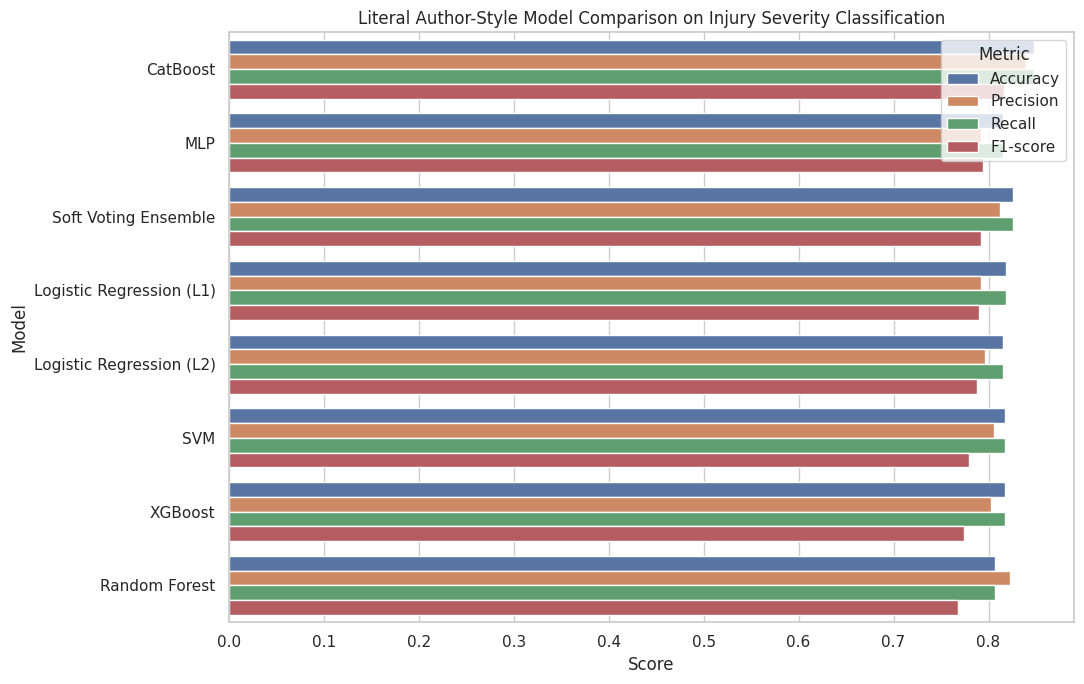

In [ ]:
all_artifacts = load_all_artifacts()
_, test_summary_df, _, _ = build_summary_frames(all_artifacts)
results_df = test_summary_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']].copy()
results_df = results_df.sort_values(by='F1-score', ascending=False).reset_index(drop=True)

print('Final test comparison table:')
display(results_df)

plot_df = results_df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score'],
    var_name='Metric',
    value_name='Score',
)

fig, ax = plt.subplots(figsize=(11, 7))
if SEABORN_AVAILABLE:
    sns.barplot(data=plot_df, x='Score', y='Model', hue='Metric', ax=ax)
else:
    pivot_df = plot_df.pivot(index='Model', columns='Metric', values='Score')
    pivot_df = pivot_df.loc[results_df['Model']]
    pivot_df.plot(kind='barh', ax=ax)

ax.set_title('Literal Author-Style Model Comparison on Injury Severity Classification')
ax.set_xlabel('Score')
ax.set_ylabel('Model')
ax.legend(title='Metric')
fig.tight_layout()
plt.show()
